In [1]:
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('clear', '')
    get_ipython().run_line_magic('reset', '-f')
except:
    pass


# Carga de librerias

In [2]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aplicar el estilo ggplot
plt.style.use('ggplot')

# Carga de datos

In [4]:
df_SIP2 = pd.read_csv(r'SIP3.csv')
# df_SIP2.drop(columns=['Unnamed: 0', 'LocalTime'], inplace=True)
print(df_SIP2.head(20))

    Time (h)  Valve (%)  Pressure (psi)  Temperature (°C)
0   0.000000          0           -0.04             27.91
1   0.002778          0           -0.07             27.57
2   0.005556          0           -0.06             27.37
3   0.008333          0           -0.06             27.24
4   0.011111          0           -0.05             27.22
5   0.013889          0           -0.05             27.21
6   0.016667          0           -0.04             27.21
7   0.019444          0           -0.05             27.21
8   0.022222          0           -0.05             27.23
9   0.025000          0           -0.04             27.21
10  0.027778          0           -0.05             27.22
11  0.030556          0           -0.05             27.24
12  0.033333          0           -0.04             27.24
13  0.036111          0           -0.05             27.25
14  0.038889          0           -0.04             27.28
15  0.041667          0           -0.04             27.31
16  0.044444  

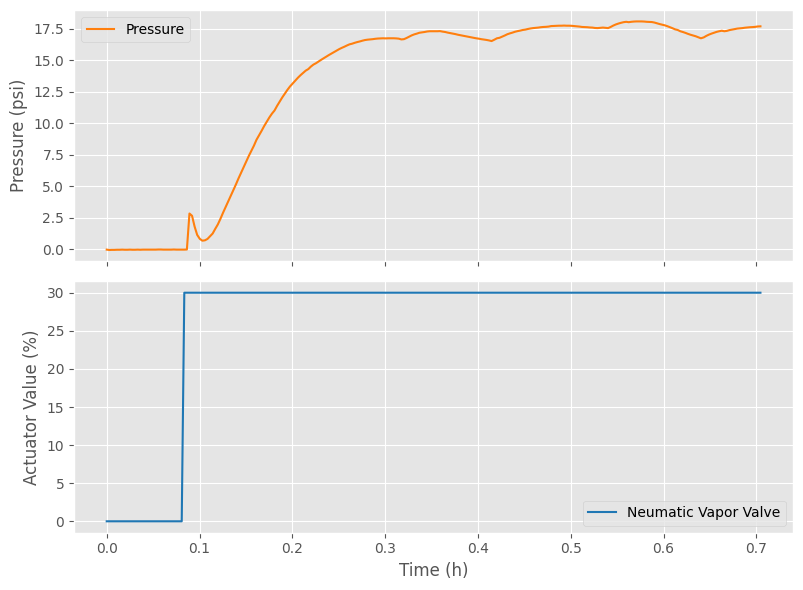

In [5]:
# Crear subplots: 2 filas, 1 columna. Compartimos el eje X.
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

# --- Primera fila: Presión ---
ax1.plot(df_SIP2['Time (h)'], df_SIP2['Pressure (psi)'], color='tab:orange', label='Pressure')
ax1.set_ylabel('Pressure (psi)')
ax1.legend()

# --- Segunda fila: Porcentaje de apertura de la válvula ---
ax2.plot(df_SIP2['Time (h)'], df_SIP2['Valve (%)'], color='tab:blue', label='Neumatic Vapor Valve')
ax2.set_ylabel('Actuator Value (%)')
ax2.set_xlabel('Time (h)')
ax2.legend()

# Ajustar el diseño para que se vea limpio y no se crucen los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# Obtención de FT 1er orden discreta

--- Parámetros Identificados (Modelo Discreto) ---
Ganancia (K): 0.5919 psi/%
Constante de tiempo (tau): 0.0768 h
Tiempo muerto (theta): 0.0200 h
Retraso entero (d): 7 muestras


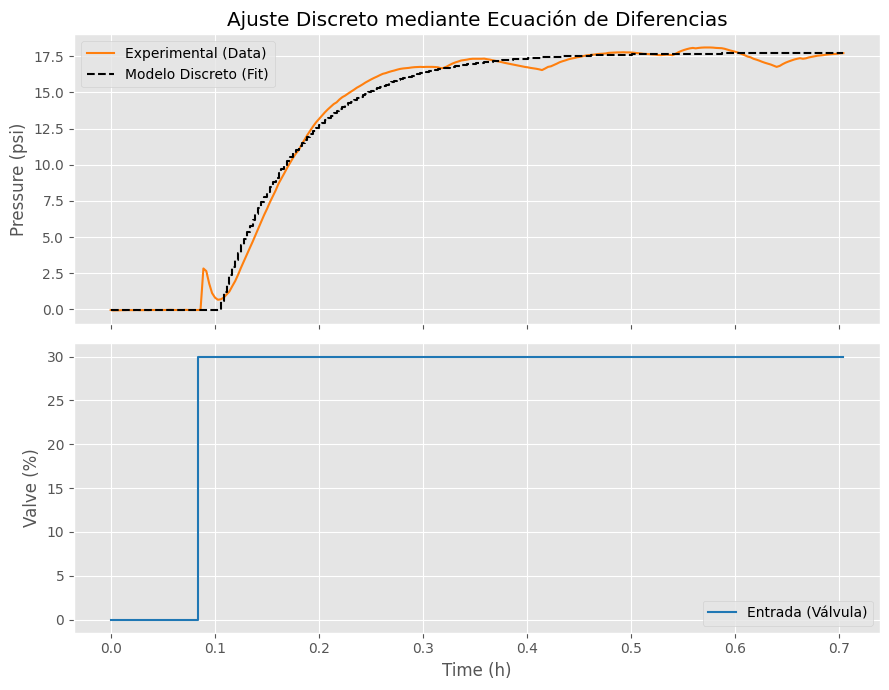

In [6]:
# 1. Configuración de parámetros de muestreo
# 10 segundos expresados en horas
Ts = 10 / 3600 

# Extraer arreglos
t = df_SIP2['Time (h)'].values
u = df_SIP2['Valve (%)'].values
y = df_SIP2['Pressure (psi)'].values

# Variables de desviación
u0, y0 = u[0], y[0]
u_dev = u - u0
y_dev = y - y0

# Identificar el inicio del escalón
step_idx = np.where(np.abs(u_dev) > 0.1)[0][0]

# 2. Definición del modelo de ecuación de diferencias
def discrete_fopdt_model(t_array, K, tau, theta):
    """
    Simula la respuesta de un modelo discreto:
    y[k] = a*y[k-1] + b*u[k-d-1]
    donde:
    a = exp(-Ts/tau)
    b = K * (1 - a)
    d = theta // Ts (retraso entero)
    """
    y_sim = np.zeros(len(t_array))
    
    # Parámetros del modelo discreto
    a = np.exp(-Ts / tau)
    b = K * (1 - a)
    d = int(max(0, theta // Ts)) # Número de muestras de retraso
    
    # Simulación recursiva (Ecuación de diferencias)
    for k in range(1, len(t_array)):
        # Aplicamos el retraso a la entrada u
        idx_u = k - d - 1
        u_delayed = u_dev[idx_u] if idx_u >= step_idx else 0
        
        y_sim[k] = a * y_sim[k-1] + b * u_delayed
        
    return y_sim

# 3. Ajuste de parámetros (K, tau, theta)
# Suposiciones iniciales: Ganancia=0.6, Tau=0.08, Theta=0.02
p0_guess = [0.6, 0.08, 0.02]
bounds = ([0.01, 0.001, 0], [10.0, 1.0, 0.2]) # Límites físicos

popt, _ = curve_fit(discrete_fopdt_model, t, y_dev, p0=p0_guess, bounds=bounds)
K_disc, tau_disc, theta_disc = popt

# 4. Resultados y Visualización
y_pred_dev = discrete_fopdt_model(t, K_disc, tau_disc, theta_disc)
y_pred = y_pred_dev + y0

print(f"--- Parámetros Identificados (Modelo Discreto) ---")
print(f"Ganancia (K): {K_disc:.4f} psi/%")
print(f"Constante de tiempo (tau): {tau_disc:.4f} h")
print(f"Tiempo muerto (theta): {theta_disc:.4f} h")
print(f"Retraso entero (d): {int(theta_disc//Ts)} muestras")

# Graficar
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(t, y, 'tab:orange', label='Experimental (Data)')
ax1.step(t, y_pred, 'k--', where='post', label='Modelo Discreto (Fit)')
ax1.set_ylabel('Pressure (psi)')
ax1.set_title('Ajuste Discreto mediante Ecuación de Diferencias')
ax1.legend()

ax2.step(t, u, 'tab:blue', where='post', label='Entrada (Válvula)')
ax2.set_ylabel('Valve (%)')
ax2.set_xlabel('Time (h)')
ax2.legend()

plt.tight_layout()
plt.show()

# Sintonia de controlador y testeo

--- Parámetros PID Calculados (IAE Set-point) ---
Ganancia Proporcional (Kc) : 4.0786 % psi
Tiempo Integral (Ti)       : 0.0488 h
Tiempo Derivativo (Td)     : 0.0072 h


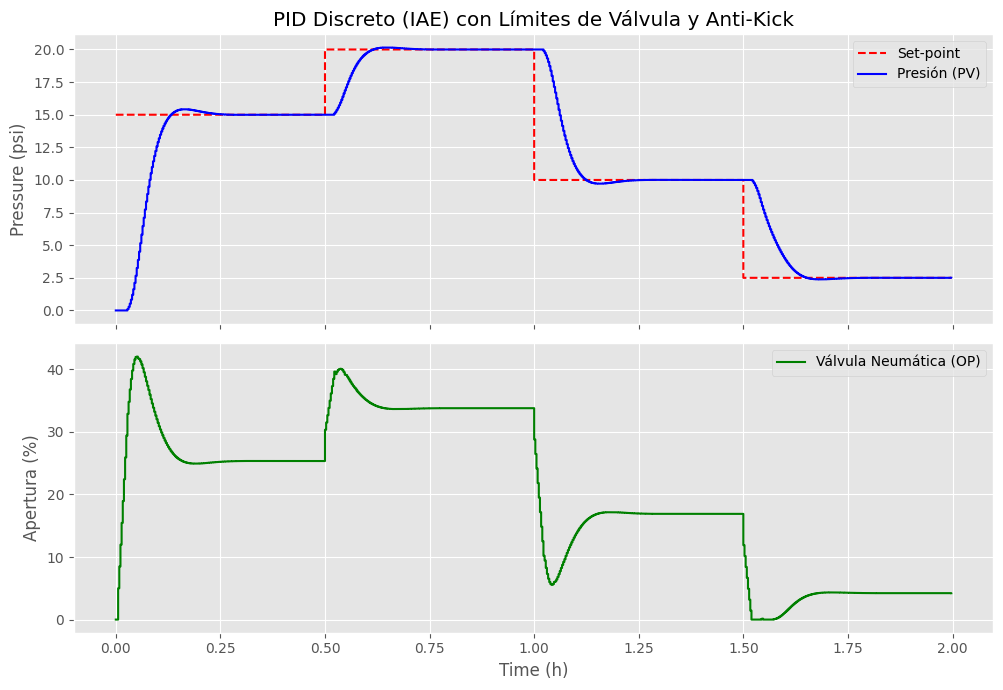

In [7]:
# --- 1. Parámetros del modelo FOPDT Discreto ---
K = K_disc                    # 0.6086 psi/%  
tau = tau_disc                # 0.0995 h
theta = theta_disc            # 0.0200 h
Ts = 10 / 3600                # Periodo de muestreo: 10 segundos en horas
d = int(np.round(theta / Ts)) # Retraso discreto (7 muestras)

# --- 2. Sintonización PID usando criterios IAE (Set-point Tracking) ---
# Relación de inercia/retraso (adimensional)
ratio = theta / tau

# Fórmulas empíricas de sintonización IAE para Set-point
Kc = (0.758 / K) * (ratio)**(-0.861)
Ti = (tau / 1.020) * (ratio)**(0.323)
Td = 0.323 * tau * (ratio)**(0.920)

print("--- Parámetros PID Calculados (IAE Set-point) ---")
print(f"Ganancia Proporcional (Kc) : {Kc:.4f} % psi")
print(f"Tiempo Integral (Ti)       : {Ti:.4f} h")
print(f"Tiempo Derivativo (Td)     : {Td:.4f} h")

# --- RESTRICCIONES FÍSICAS DE LA VÁLVULA ---
OP_MIN = 0.0    # Cierre total
OP_MAX = 100.0  # Apertura total
# Rate Limiter: Máximo cambio permitido de la válvula por cada 10 segundos.
# Ajusta este valor según la hoja de datos de tu actuador neumático.
MAX_DELTA_OP = 5.0 # Ejemplo: La válvula no se moverá más de un 5% cada 10s

# --- 3. Simulación del Lazo Cerrado ---
t_sim = np.arange(0, 2, Ts)
n_steps = len(t_sim)

# Perfil de Set-point
sp = np.zeros(n_steps)
sp[t_sim < 0.5] = 15
sp[(t_sim >= 0.5) & (t_sim < 1.0)] = 20
sp[(t_sim >= 1.0) & (t_sim < 1.5)] = 10
sp[t_sim >= 1.5] = 2.5

pv = np.zeros(n_steps)
op = np.zeros(n_steps)
e = np.zeros(n_steps)

# Coeficientes de la planta
a = np.exp(-Ts / tau)
b = K * (1 - a)

# Bucle de Control
for k in range(2, n_steps):
    # 1. Medición y cálculo del error
    e[k] = sp[k] - pv[k-1] 
    
    # 2. Algoritmo PID Discreto (Evitando Kicks)
    # Proporcional sobre el Error
    delta_P = Kc * (e[k] - e[k-1])
    # Integral sobre el Error
    delta_I = (Kc * Ts / Ti) * e[k]
    # Derivativo sobre la PV (presión real), no sobre el error
    # Se usa el signo negativo porque la respuesta busca compensar el cambio
    if k >= 3:
        delta_D = (Kc * Td / Ts) * (-pv[k-1] + 2*pv[k-2] - pv[k-3])
    else:
        delta_D = 0
        
    delta_op_calc = delta_P + delta_I + delta_D
    
    # 3. Aplicar "Rate Limiter" (Slew Rate) a la válvula
    delta_op_real = np.clip(delta_op_calc, -MAX_DELTA_OP, MAX_DELTA_OP)
    
    # 4. Calcular nueva salida y saturación absoluta
    op_unclamped = op[k-1] + delta_op_real
    op[k] = np.clip(op_unclamped, OP_MIN, OP_MAX)
    
    # 5. Simulación de la planta (Modelo Discreto con Retraso)
    idx_u = k - d - 1
    u_delayed = op[idx_u] if idx_u >= 0 else 0
    pv[k] = a * pv[k-1] + b * u_delayed

# --- 4. Graficar Resultados ---
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.step(t_sim, sp, 'r--', where='post', label='Set-point')
ax1.step(t_sim, pv, 'b-', where='post', label='Presión (PV)')
ax1.set_ylabel('Pressure (psi)')
ax1.set_title('PID Discreto (IAE) con Límites de Válvula y Anti-Kick')
ax1.legend()

ax2.step(t_sim, op, 'g-', where='post', label='Válvula Neumática (OP)')
ax2.set_ylabel('Apertura (%)')
ax2.set_xlabel('Time (h)')
ax2.legend()
plt.tight_layout()
plt.show()

# Simulador en producion resultados

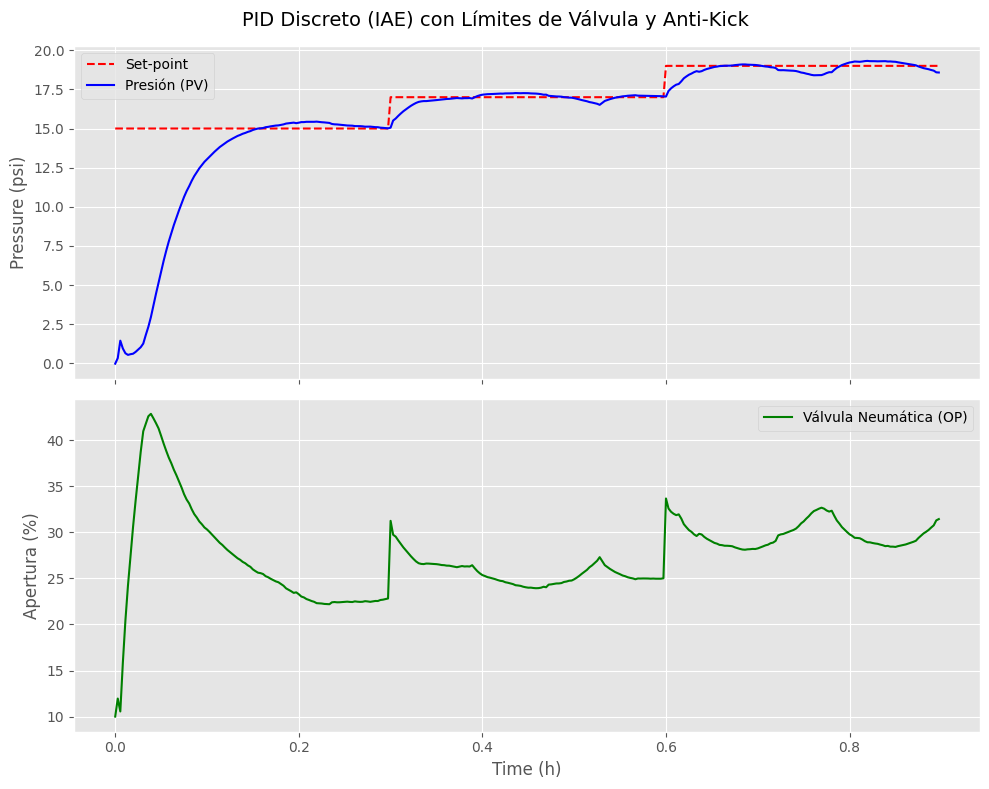

In [4]:
# 1. Cargar los datos desde el archivo CSV
# Asegúrate de que el archivo 'plc_control_log.csv' esté en el mismo directorio que este script
df = pd.read_csv('plc_control_log.csv')

# 2. Configurar el estilo del gráfico
plt.style.use('ggplot')

# 3. Crear la figura y los subplots (2 filas, 1 columna, compartiendo el eje X)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Título general de la figura
fig.suptitle('PID Discreto (IAE) con Límites de Válvula y Anti-Kick', fontsize=14)

# --- Primer Subplot (Arriba): Setpoint vs Presión (PV) ---
ax1.plot(df['Time_h'], df['Setpoint_psi'], 'r--', label='Set-point')
ax1.plot(df['Time_h'], df['Pressure_psi'], 'b-', label='Presión (PV)')
ax1.set_ylabel('Pressure (psi)', fontsize=12)
ax1.legend(loc='upper left')

# --- Segundo Subplot (Abajo): Apertura de Válvula (OP) ---
ax2.plot(df['Time_h'], df['Valve_pct'], 'g-', label='Válvula Neumática (OP)')
ax2.set_ylabel('Apertura (%)', fontsize=12)
ax2.set_xlabel('Time (h)', fontsize=12)
ax2.legend(loc='upper right')

# 4. Ajustar el diseño para que no se superpongan los textos
plt.tight_layout()

# 5. Mostrar el gráfico
plt.show()